In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset from the data folder
file_path = '../data/london_crime_by_lsoa.csv' 
df = pd.read_csv(file_path)

In [5]:
print("--- 1. First 5 Rows of the Data ---")
display(df.head())

print("\n--- 2. Dataframe Info (Structure and Types) ---")
df.info()

print("\n--- 3. Checking for Missing Values ---")
print(df.isnull().sum())
# MY finding: No missing values! Great news.

--- 1. First 5 Rows of the Data ---


,lsoa_code,borough,major_category,minor_category,value,year,month
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6



--- 2. Dataframe Info (Structure and Types) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13490604 entries, 0 to 13490603
Data columns (total 7 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   lsoa_code       object
 1   borough         object
 2   major_category  object
 3   minor_category  object
 4   value           int64 
 5   year            int64 
 6   month           int64 
dtypes: int64(3), object(4)
memory usage: 720.5+ MB

--- 3. Checking for Missing Values ---
lsoa_code         0
borough           0
major_category    0
minor_category    0
value             0
year              0
month             0
dtype: int64


In [6]:
print("\n--- 4. Summary Statistics (to find outliers) ---")
display(df.describe())
# MY finding: The 'max' value of 309 in the 'value' column is a significant outlier.

print("\n--- 5. Creating a Proper 'date' Column for Time-Series Analysis ---")
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print("Successfully created the 'date' column.")
display(df.head())


--- 4. Summary Statistics (to find outliers) ---


,value,year,month
count,1.349060e+07,1.349060e+07,1.349060e+07
mean,4.779444e-01,2.012000e+03,6.500000e+00
std,1.771513e+00,2.581989e+00,3.452053e+00
min,0.000000e+00,2.008000e+03,1.000000e+00
25%,0.000000e+00,2.010000e+03,3.750000e+00
50%,0.000000e+00,2.012000e+03,6.500000e+00
75%,1.000000e+00,2.014000e+03,9.250000e+00
max,3.090000e+02,2.016000e+03,1.200000e+01



--- 5. Creating a Proper 'date' Column for Time-Series Analysis ---
Successfully created the 'date' column.


,lsoa_code,borough,major_category,minor_category,value,year,month,date
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11,2016-11-01
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11,2016-11-01
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5,2015-05-01
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3,2016-03-01
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6,2008-06-01



--- 6. Investigating the Outlier (The Hotspot) ---
Finding the record(s) with the highest crime count:


,lsoa_code,borough,major_category,minor_category,value,year,month,date
1608904,E01004234,Tower Hamlets,Drugs,Possession Of Drugs,309,2012,6,2012-06-01



--- 7. Visualizing the Crime Timeline ---


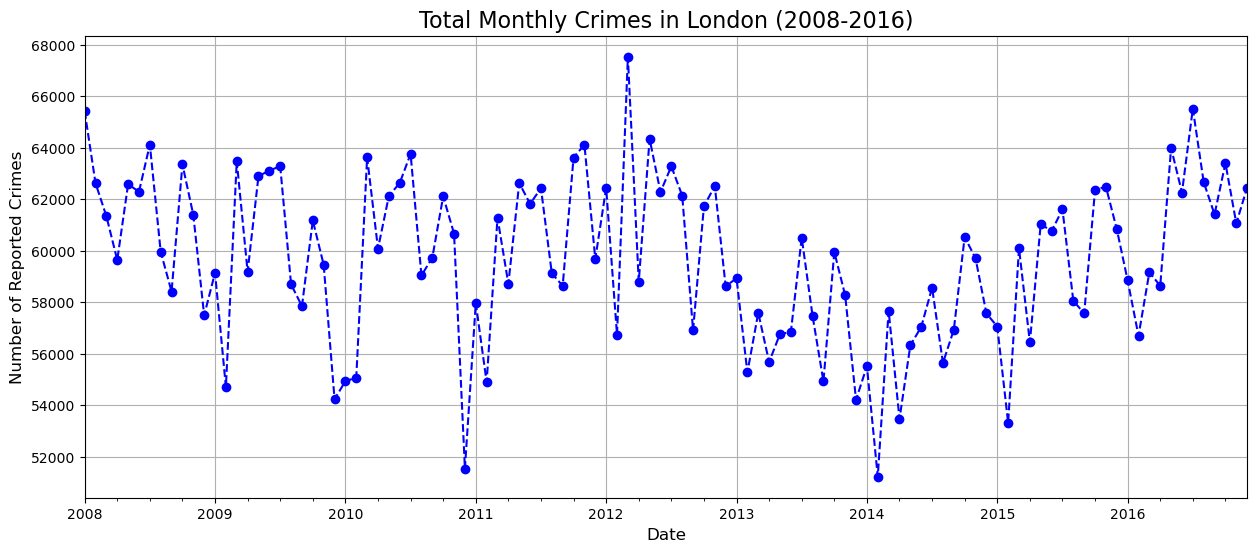

In [7]:
print("\n--- 6. Investigating the Outlier (The Hotspot) ---")
print("Finding the record(s) with the highest crime count:")
display(df[df['value'] == df['value'].max()])

print("\n--- 7. Visualizing the Crime Timeline ---")
# Group the data by our new 'date' column and sum up all the crime values for each month
monthly_crimes = df.groupby('date')['value'].sum()

# Create the plot
plt.figure(figsize=(15, 6)) # Make the plot nice and big
monthly_crimes.plot(kind='line', color='blue', marker='o', linestyle='--') # Plot as a styled line chart

# Add titles and labels to make it professional
plt.title('Total Monthly Crimes in London (2008-2016)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Number of Reported Crimes', fontsize=12)
plt.grid(True) # Add a grid for easier reading
plt.show() # Display the plot

--- Total Crimes by Borough (2008-2016) ---


borough
Westminster               455028
Lambeth                   292178
Southwark                 278809
Camden                    275147
Newham                    262024
Croydon                   260294
Ealing                    251562
Islington                 230286
Tower Hamlets             228613
Brent                     227551
Hackney                   217119
Lewisham                  215137
Haringey                  213272
Barnet                    212191
Hillingdon                209680
Wandsworth                204741
Waltham Forest            203879
Enfield                   193880
Hounslow                  186772
Hammersmith and Fulham    185259
Bromley                   184349
Redbridge                 183562
Greenwich                 181568
Kensington and Chelsea    171981
Barking and Dagenham      149447
Havering                  138947
Harrow                    116848
Merton                    115654
Bexley                    114136
Sutton                    100987
Ri

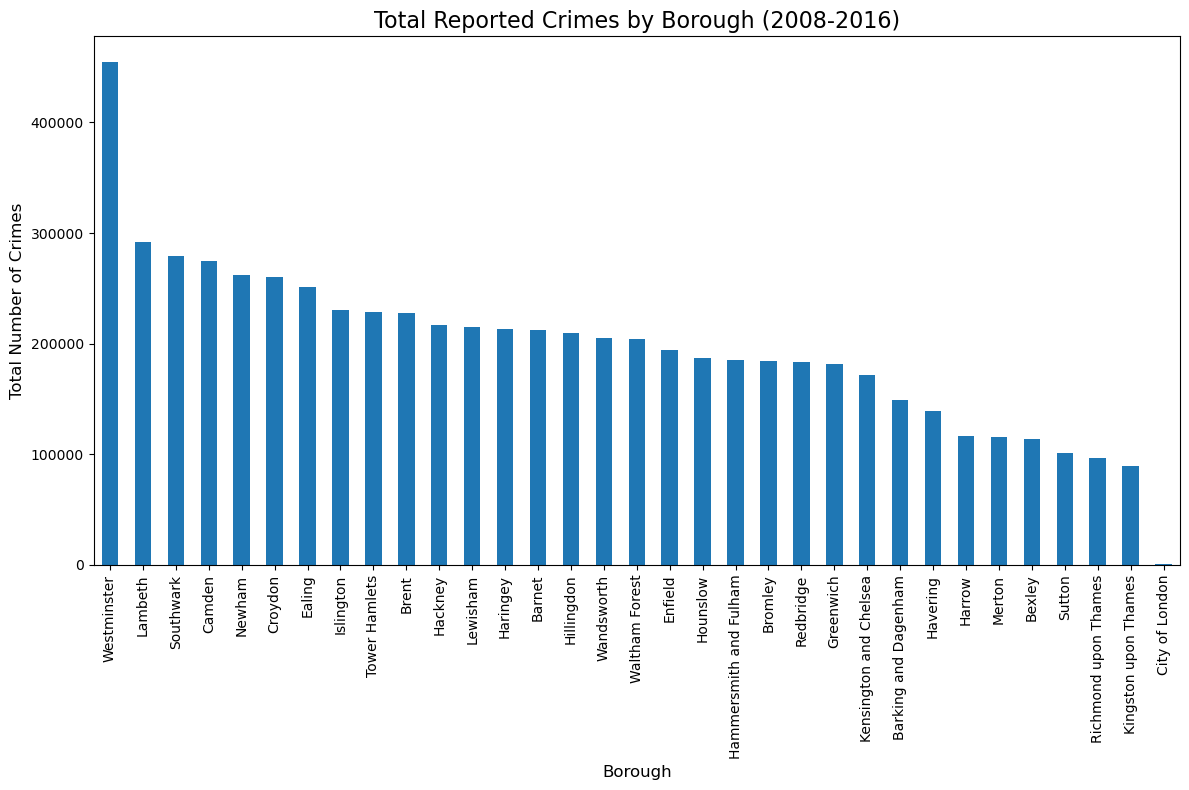

In [8]:
# --- 8. Geographical Analysis: Crime by Borough ---

# Group by borough and sum the number of crimes
borough_crimes = df.groupby('borough')['value'].sum().sort_values(ascending=False)

print("--- Total Crimes by Borough (2008-2016) ---")
display(borough_crimes)

# Now, let's visualize this with a bar chart
plt.figure(figsize=(12, 8))
borough_crimes.plot(kind='bar') # Create a bar chart

# Add titles and labels
plt.title('Total Reported Crimes by Borough (2008-2016)', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Number of Crimes', fontsize=12)
plt.xticks(rotation=90) # Rotate the borough names so they don't overlap
plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
plt.show()

--- Total Crimes by Borough (2008-2016) ---


borough
Westminster               455028
Lambeth                   292178
Southwark                 278809
Camden                    275147
Newham                    262024
Croydon                   260294
Ealing                    251562
Islington                 230286
Tower Hamlets             228613
Brent                     227551
Hackney                   217119
Lewisham                  215137
Haringey                  213272
Barnet                    212191
Hillingdon                209680
Wandsworth                204741
Waltham Forest            203879
Enfield                   193880
Hounslow                  186772
Hammersmith and Fulham    185259
Bromley                   184349
Redbridge                 183562
Greenwich                 181568
Kensington and Chelsea    171981
Barking and Dagenham      149447
Havering                  138947
Harrow                    116848
Merton                    115654
Bexley                    114136
Sutton                    100987
Ri

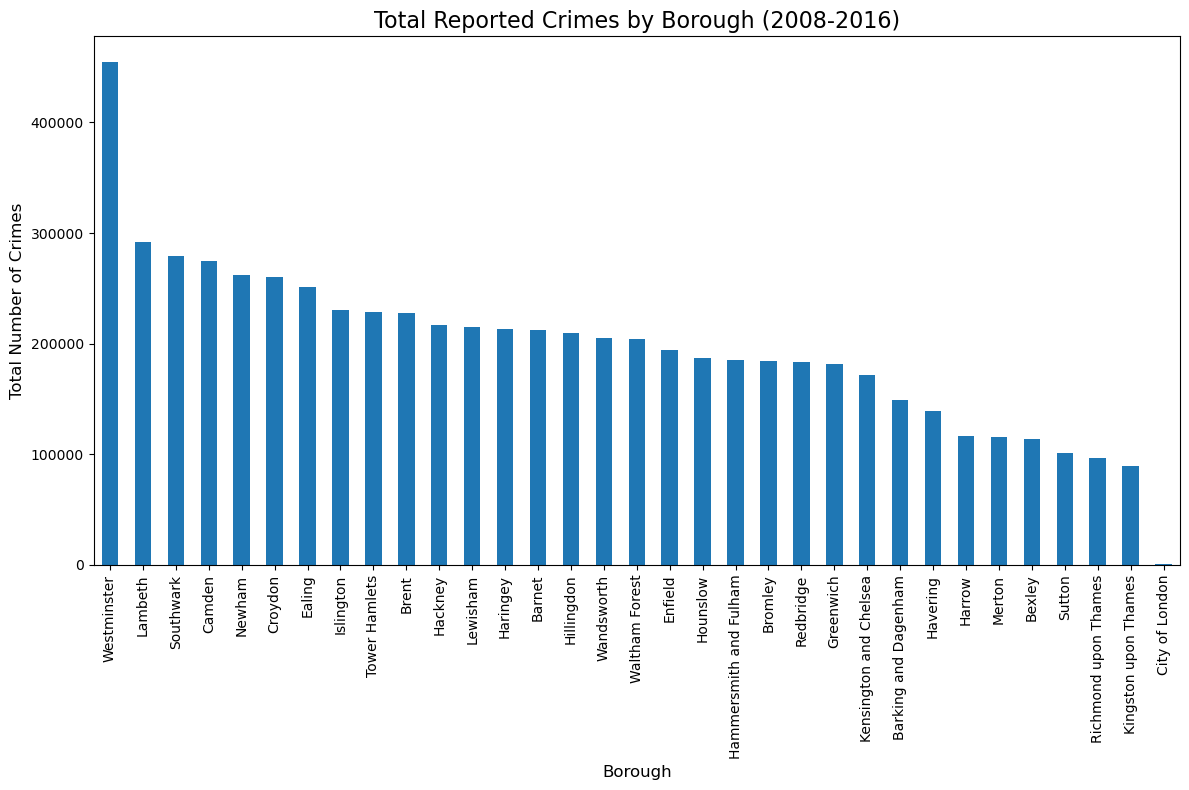

In [9]:
# --- 8. Geographical Analysis: Crime by Borough ---

# Group by borough and sum the number of crimes
borough_crimes = df.groupby('borough')['value'].sum().sort_values(ascending=False)

print("--- Total Crimes by Borough (2008-2016) ---")
display(borough_crimes)

# Now, let's visualize this with a bar chart
plt.figure(figsize=(12, 8))
borough_crimes.plot(kind='bar') # Create a bar chart

# Add titles and labels
plt.title('Total Reported Crimes by Borough (2008-2016)', fontsize=16)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Total Number of Crimes', fontsize=12)
plt.xticks(rotation=90) # Rotate the borough names so they don't overlap
plt.tight_layout() # Adjust plot to ensure everything fits without overlapping
plt.show()